# Part 1: Plotting Contact Maps w/ Cooltools
### Use the coolToolsPlotting kernel

In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import cooltools
import cooler
import re

from matplotlib.ticker import EngFormatter
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib.ticker import FuncFormatter

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

bp_formatter = EngFormatter('b')

        
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from mpl_toolkits.axes_grid1 import make_axes_locatable


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

In [3]:
def get_coords(locus_str):
    m = re.search(r'(chr\d+):(\d+)-(\d+)', locus_str)
    chrom = m.group(1)
    start_coord = int(m.group(2))
    end_coord = int(m.group(3))

    return chrom, start_coord, end_coord

In [4]:

def sci_notation(num, decimal_digits=1, precision=None, exponent=None):
    """
    Returns a string representation of the scientific
    notation of the given number formatted for use with
    LaTeX or Mathtext, with specified number of significant
    decimal digits and precision (number of decimal digits
    to show). The exponent to be used can also be specified
    explicitly.
    """
    return r"$10^{{{0:d}}}$".format(num)

@FuncFormatter
def my_formatter(x, pos):
     return "{}".format(10^{x})
#cbar_format_2 = r"10^{{{0:d}}}".format


def plotter(region):
    
    f, axs = plt.subplots(
    figsize=(20, 20),
    nrows=1,
    ncols=1,
    sharex=True,
    sharey=False
    )
    
    chrom, start, end = get_coords(region)
    extents = (start, end, end, start)
    norm_balanced = LogNorm(vmax=0.1) # the vmax is tunable 
    cbar_format = FormatStrFormatter('%.2f')

    mat = clr.matrix(balance=True).fetch(region)
    ax = axs
    ax.set_title('Test')
    im2 = ax.matshow(
        mat,
        cmap='fall',
        extent=extents, 
        norm=norm_balanced
    );
    cb = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label='contact frequency', ticks = [10e-4, 10e-3, 10e-2], location='left');
    
    return f



def format_ticks(ax, x=True, y=False, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)
        
#labels = [sci_notation(x) for x in [-4, -3, -2]]
#print(labels)
#cb.ax.set_yticklabels(labels)
#cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(my_formatter))

# for ax in axs.ravel():
#     format_ticks(ax, rotate=False)
#     ax.set_yticks([])
# plt.tight_layout()

# plt.savefig(f'/home/viraat/Scripts/TMC_Figures/Figure2_ContactMaps/Klf1_AllUComps_500bp.svg', dpi=1200)

## LINEAR TIME COURSE PLOTTING

In [5]:
coords = {'Casgevy':60495265, 'Casgevy2':60500565, 'BCL11A':60553498, 'BCL2':60560498, 'REL':60881494, 'PAPOLG':60756229, 'LNC':60335016, 'ING1':60678000}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01,'Casgevy_REL':0.002, 'BCL11A_REL':0.0025,'BCL11A_PAPOLG':0.0025, 'BCL11A_ING1':0.01}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01, 'BCL11A_REL':0.0025,'BCL2_ING1':0.01}


In [100]:
# load coolers 
resolution = 2000
phases = ['Phase1_', 'Phase2_dedup',  'Phase3_dedup']
cooler_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
cooler_names = [os.path.join(cooler_path, f"Sankaran_{p}merged.250.mcool") for p in phases]
COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]


phases_rcmc = {1: 'P1', 2:'P2', 3:'P3'}
phases_microc = {1: 'Phase1_', 2:'Phase2_dedup',3:'Phase3_dedup'}
rcmc_fnames = [f'/mnt/coldstorage/Varshmallow/Blood_RCMC/RCMC_Blood_{phases_rcmc[phase]}_allCap_hg38.merged.50.mcool' for phase in phases_rcmc]
COOLERS = [utils.get_clr(clr_name, resolution) for clr_name in rcmc_fnames]

In [101]:
# coords = {'MYBTSS':135181308, 'MYBTTS':135219173, 'HBINT':135100000, 'AHINT':135400000}
# #coords = {'MYBLV':135186308, 'MYBTTS':135219173, 'HBINT':135100000, 'AHINT':135425000}
# coords = {'MYBTSS':135186308, 'MYBLV':135150000, 'HBINT':135050000, 'AHINT':135425000}
# loops = {'MYBLV_MYBTSS':0.025, 'MYBTSS_AHINT':0.01,'MYBLV_AHINT':0.01, 'HBINT_MYBTSS':0.01}

# coords = {'HBB': 5227200, 'E1':5280650, 'E2': 5288300}
# loops = {'HBB_E1': 0.025}

# loop_dict defines the max intensities of the loops
# coord dict defines the anchors that are paired 
def plot_loops_region(region, loops,  res, coord_dict=None, loop_dict=None, size_kb=200, norm=LogNorm(),
                     gridspec = {'width_ratios': [1, 1, 1]}, size_kb2 = None, vmin=0.0001, vmax=0.01, sd=None):
    
    chrom, start_coord, end_coord = get_coords(region)
    
    #for pair, thresh in loops.items():
    for _, loop_row in loops.iterrows():
        print(loop_row)
        
        f, axs = plt.subplots(
        figsize=(12, 24),
        nrows=1,
        ncols=3,
        sharex=True,
        sharey=False,
        gridspec_kw=gridspec
        )
        
        for phase in range(3):
            print(phase)
            curr_cooler = COOLERS[phase]
            mat = curr_cooler.matrix(balance=True).fetch(region)

#             p1, p2 = pair.split('_')
#             c1 = coords[p1] 
#             c2 = coords[p2]
            
            c1 = loop_row['start1']+2500
            c2 = loop_row['start2']+2500
            
            # subset the matrix in pix
            c1_pix = (c1-start_coord) // res 
            c2_pix = (c2-start_coord) // res 

            # convert the window to pixels
            window_pix = (size_kb*1000)//res
            
            if size_kb2 is None: 
                sub_mat = mat[c1_pix-window_pix:c1_pix+window_pix, c2_pix-window_pix:c2_pix+window_pix]
                extents = [c1_pix-window_pix,c1_pix+window_pix,c2_pix-window_pix,c2_pix+window_pix]
            else:
              # plot
                window_pix2 = (size_kb2*1000)//res

                sub_mat = mat[c1_pix-window_pix:c1_pix+window_pix, c2_pix-window_pix2:c2_pix+window_pix2]
                #extents = [c1_pix-window_pix,c1_pix+window_pix,c2_pix-window_pix2,c2_pix+window_pix2]
            ax = axs[phase]
            
            #ax.set_title(f"Phase {phase}")
            im2 = ax.matshow(
                sub_mat,
                cmap='fall',
                norm=LogNorm(vmin=vmin, vmax=vmax),
                aspect='equal'
            );

#         for axes in axs:
#             axes.set_aspect(1)

        for ax in axs.ravel():
            ax.set_xticks([])
            ax.set_yticks([])

        ax_divider = make_axes_locatable(ax)
#         cax = ax_divider.append_axes("right", size=0.09, pad=0.2)
#         #cb = plt.colorbar(im2, cax=cax, ticks = [0, thresh], location='right');
#         cb = plt.colorbar()
        #fileName = f"phasePlot_{pair}.svg"
        if sd is not None:
            plt.savefig(sd)
        else:
            plt.show()
        
        #plt.savefig(saveDir + fileName, dpi=1200)
        
def plot_region_bounds(region, bounds,  res, coord_dict=None, loop_dict=None, size_kb=200, norm=LogNorm(),
                     gridspec = {'width_ratios': [1, 1, 1]}, size_kb2 = None, vmin=0.0001, vmax=0.01, sd=None):
    
    chrom, start_coord, end_coord = get_coords(region)
    
    #for pair, thresh in loops.items():
    for _, bound_row in loops.iterrows():
        print(bound_row)
        
        f, axs = plt.subplots(
        figsize=(12, 24),
        nrows=1,
        ncols=3,
        sharex=True,
        sharey=False,
        gridspec_kw=gridspec
        )
        
        for phase in range(3):
            print(phase)
            curr_cooler = COOLERS[phase]
            mat = curr_cooler.matrix(balance=True).fetch(region)

            
            c1_start = bound_row['start1']
            c1_end = bound_row['end1']
            c2_start = bound_row['start2']
            c2_end = bound_row['end2']
            
            # subset the matrix in pix
            c1_start_pix = (c1_start-start_coord) // res 
            c1_end_pix = (c1_end-start_coord) // res 
            c2_start_pix = (c1_start-start_coord) // res 
            c2_end_pix = (c2_end-start_coord) // res 

            sub_mat = mat[c1_start_pix:c1_end_pix, c2_start_pix:c2_end_pix]
            ax = axs[phase]
            
            #ax.set_title(f"Phase {phase}")
            im2 = ax.matshow(
                sub_mat,
                cmap='fall',
                norm=LogNorm(vmin=vmin, vmax=vmax),
                aspect='equal'
            );

#         for axes in axs:
#             axes.set_aspect(1)

        for ax in axs.ravel():
            ax.set_xticks([])
            ax.set_yticks([])

        ax_divider = make_axes_locatable(ax)
        if sd is not None:
            plt.savefig(sd)
        else:
            plt.show()
        
        #plt.savefig(saveDir + fileName, dpi=1200)

In [102]:
# # load coolers 
# resolution = 1000
# phases = ['Phase1_', 'Phase2_',  'Phase3_']
# cooler_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/rep_cools'
# cooler_names = [os.path.join(cooler_path, f"Sankaran_{p}Rep1.250.mcool") for p in phases]
# COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]

In [103]:
cooler_names

['/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase2_dedupmerged.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool']

In [104]:
loopcalls = pd.read_csv("/mnt/md0/varshini/Analysis/Blood/MicroC_Loops_Anchors_Merged_v2/merged_calls_125kb_q0.01_classes.txt", 
                       sep="\t").rename({'seqnames1':'chr1'}, axis=1)

In [105]:
loopcalls

,chr1,start1,end1,annotation1,seqnames2,start2,end2,annotation2,pair
0,chr1,5990001,5995000,P,chr1,6197001,6202000,P,P-P
1,chr1,5991001,5996000,P,chr1,6024001,6029000,P,P-P
2,chr1,6039001,6044000,P,chr1,6242001,6247000,P,P-P
3,chr1,6050001,6055000,CTCF,chr1,6242001,6247000,P,P-CTCF
4,chr1,6107001,6112000,CTCF,chr1,6169001,6174000,Null,CTCF-Null
...,...,...,...,...,...,...,...,...,...
63724,chrX,152950001,152955000,Null,chrX,154310001,154315000,Null,Null-Null
63725,chrX,153545001,153550000,Null,chrX,154535001,154540000,P,P-Null
63726,chrX,153740001,153745000,CTCF,chrX,154540001,154545000,P,P-CTCF
63727,chrX,155640001,155645000,Null,chrX,155955001,155960000,Null,Null-Null


In [106]:
coords = {'Casgevy':60495265, 'Casgevy2':60500565, 'BCL11A':60553498, 'BCL2':60560498, 'REL':60881494, 'PAPOLG':60756229, 'LNC':60335016, 'ING1':60678000}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01,'Casgevy_REL':0.002, 'BCL11A_REL':0.0025,'BCL11A_PAPOLG':0.0025, 'BCL11A_ING1':0.01}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01, 'BCL11A_REL':0.0025,'BCL2_ING1':0.01}
regions = {
        'BCL11A':'chr2:59964475-60946280',
        'BCL11A_full':'chr2:58164475-60976280',
        'BACH2':'chr6:89233475-90989896',
        'MYB':'chr6:134131179-135954920',
        'HBB':'chr11:5007550-5509242',
        'ZBTB7A':'chr19:3730974-4385440',
        'KLF1':'chr19:12654557-13117066',
        'loop_appear': 'chr5:173570169-174026097 ',
        'loop_disappear': 'chr7:11365292-12545212',
        'cre_vs_ctcf':"chr17:80402000-81073000",
        'cre_ctcf_2':'chr7:139026000-139387000'
}

In [107]:
reg = 'BCL11A_full'
chrom, st, ed = get_coords(regions[reg])
loopcalls_sub = loopcalls[(loopcalls['chr1']==chrom) & 
                         (loopcalls['start1'] > st) &
                         (loopcalls['end2'] < ed)].reset_index(drop=True)

In [108]:
loopcalls_sub

,chr1,start1,end1,annotation1,seqnames2,start2,end2,annotation2,pair
0,chr2,58569001,58574000,CTCF,chr2,58679001,58684000,Null,CTCF-Null
1,chr2,58569001,58574000,CTCF,chr2,58757001,58762000,E,E-CTCF
2,chr2,58613001,58618000,Null,chr2,58728001,58733000,Null,Null-Null
3,chr2,58760001,58765000,CTCF,chr2,59179001,59184000,CTCF,CTCF-CTCF
4,chr2,59023001,59028000,CTCF,chr2,59177001,59182000,Null,CTCF-Null
5,chr2,59032001,59037000,E,chr2,59167001,59172000,E,E-E
6,chr2,59032001,59037000,E,chr2,59082001,59087000,E,E-E
7,chr2,59081001,59086000,E,chr2,59175001,59180000,CTCF,E-CTCF
8,chr2,59081001,59086000,E,chr2,59179001,59184000,CTCF,E-CTCF
9,chr2,58760001,58765000,CTCF,chr2,60548001,60553000,P,P-CTCF


In [109]:
region_1 = loopcalls_sub.iloc[34:35,:]

In [110]:
savedir='/mnt/md0/varshini/Analysis/Blood/grant_figs'

In [111]:
os.path.join(savedir, "bcl11a_inset_1.svg")

'/mnt/md0/varshini/Analysis/Blood/grant_figs/bcl11a_inset_1.svg'

chr1               chr2
start1         60098501
end1           60103500
annotation1        Null
seqnames2          chr2
start2         60548501
end2           60553500
annotation2           P
pair             P-Null
Name: 34, dtype: object
0
1
2


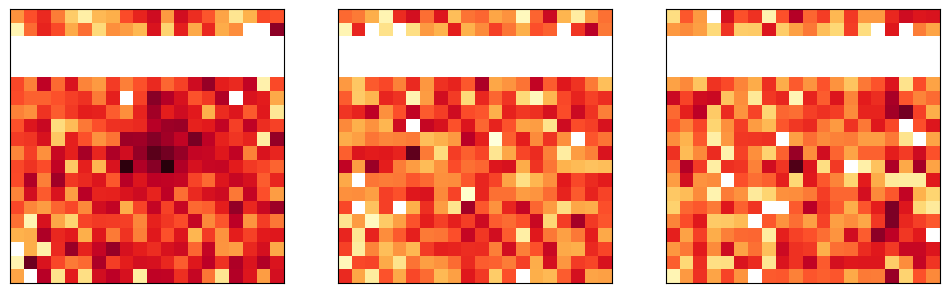

In [114]:
plot_loops_region(regions['BCL11A_full'], region_1, resolution, size_kb=20, vmax=0.005, sd=os.path.join(savedir, "bcl11a_rcmc_2kb_silencer2.svg"))

In [45]:
loopcalls_b = loopcalls_sub.iloc[31:32,:]
plot_loops_region(regions['BCL11A_full'],loopcalls_b, resolution, size_kb=400, size_kb2=200, 
                  vmin=0.00005, vmax=0.0025, sd=os.path.join(savedir, 'bcl11a_insets_2.svg'))

In [47]:
reg = 'cre_vs_ctcf'
chrom, st, ed = get_coords(regions[reg])
loopcalls_sub = loopcalls[(loopcalls['chr1']==chrom) & 
                         (loopcalls['start1'] > st) &
                         (loopcalls['end2'] < ed)].reset_index(drop=True)

In [48]:
loopcalls_sub

,chr1,start1,end1,annotation1,seqnames2,start2,end2,annotation2,pair
0,chr17,80413001,80418000,P,chr17,80452001,80457000,E,E-P
1,chr17,80423001,80428000,CTCF,chr17,80986001,80991000,P,P-CTCF
2,chr17,80424001,80429000,CTCF,chr17,80979001,80984000,CTCF,CTCF-CTCF
3,chr17,80425001,80430000,CTCF,chr17,80573001,80578000,CTCF,CTCF-CTCF
4,chr17,80425001,80430000,CTCF,chr17,80898001,80903000,CTCF,CTCF-CTCF
5,chr17,80425001,80430000,CTCF,chr17,80968001,80973000,P,P-CTCF
6,chr17,80452001,80457000,E,chr17,81032001,81037000,P,E-P
7,chr17,80453001,80458000,E,chr17,80543001,80548000,P,E-P
8,chr17,80453001,80458000,E,chr17,80989001,80994000,P,E-P
9,chr17,80455001,80460000,E,chr17,80474001,80479000,P,E-P


chr1              chr17
start1         80413001
end1           80418000
annotation1           P
seqnames2         chr17
start2         80452001
end2           80457000
annotation2           E
pair                E-P
Name: 0, dtype: object
0
1


/tmp/ipykernel_1315183/3944758386.py:61: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im2 = ax.matshow(


2


chr1              chr17
start1         80423001
end1           80428000
annotation1        CTCF
seqnames2         chr17
start2         80986001
end2           80991000
annotation2           P
pair             P-CTCF
Name: 1, dtype: object
0
1
2


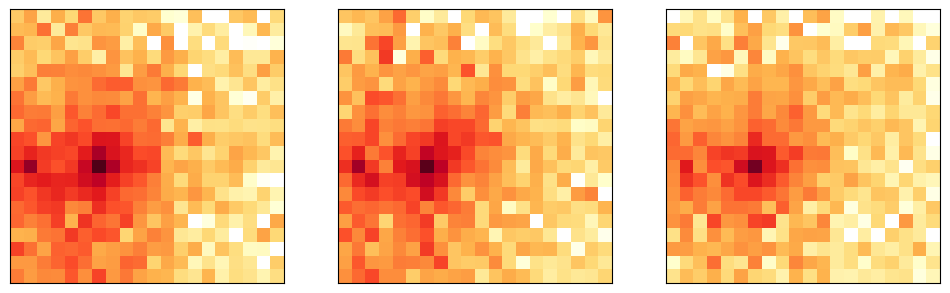

chr1               chr17
start1          80424001
end1            80429000
annotation1         CTCF
seqnames2          chr17
start2          80979001
end2            80984000
annotation2         CTCF
pair           CTCF-CTCF
Name: 2, dtype: object
0
1
2


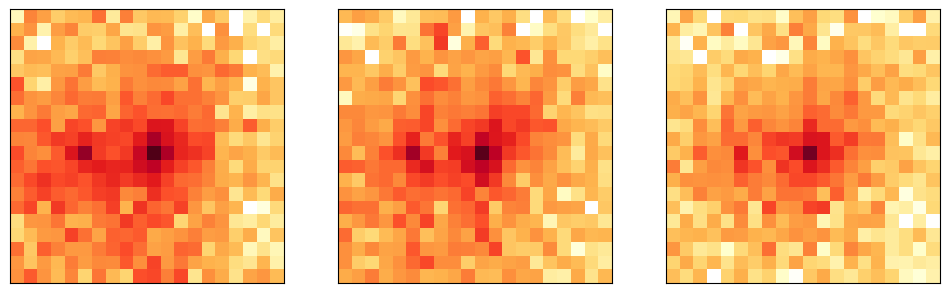

chr1               chr17
start1          80425001
end1            80430000
annotation1         CTCF
seqnames2          chr17
start2          80573001
end2            80578000
annotation2         CTCF
pair           CTCF-CTCF
Name: 3, dtype: object
0
1
2


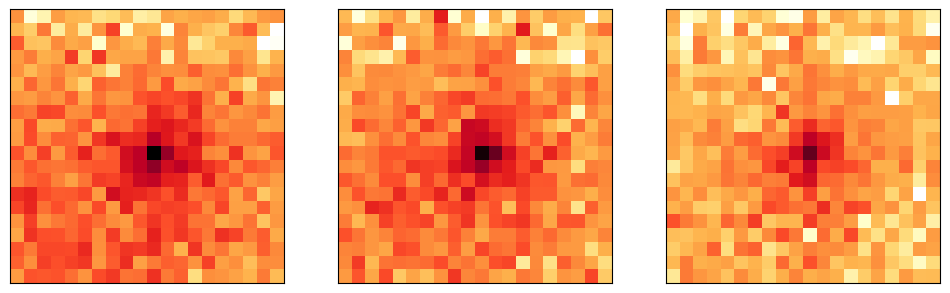

chr1               chr17
start1          80425001
end1            80430000
annotation1         CTCF
seqnames2          chr17
start2          80898001
end2            80903000
annotation2         CTCF
pair           CTCF-CTCF
Name: 4, dtype: object
0
1
2


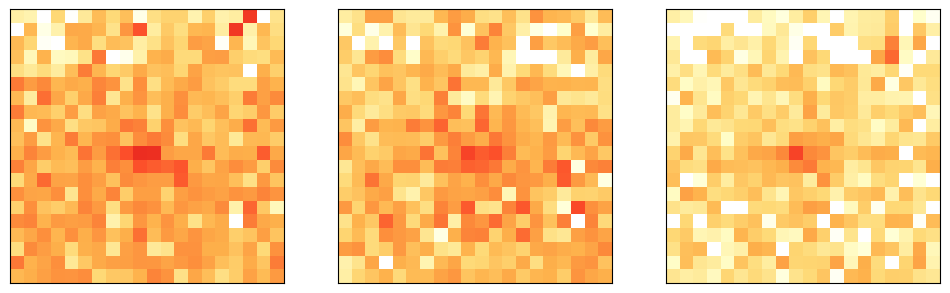

chr1              chr17
start1         80425001
end1           80430000
annotation1        CTCF
seqnames2         chr17
start2         80968001
end2           80973000
annotation2           P
pair             P-CTCF
Name: 5, dtype: object
0
1
2


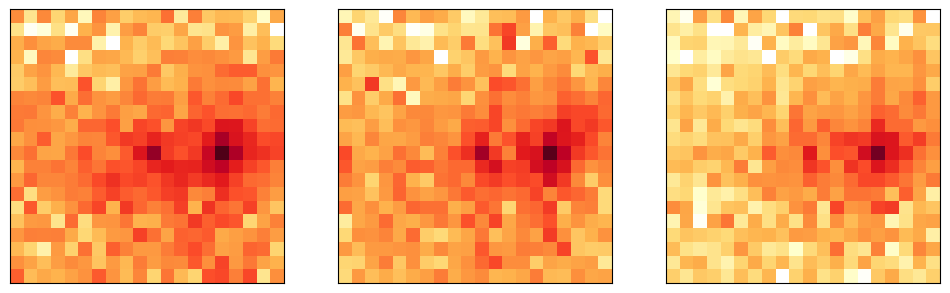

chr1              chr17
start1         80452001
end1           80457000
annotation1           E
seqnames2         chr17
start2         81032001
end2           81037000
annotation2           P
pair                E-P
Name: 6, dtype: object
0
1
2


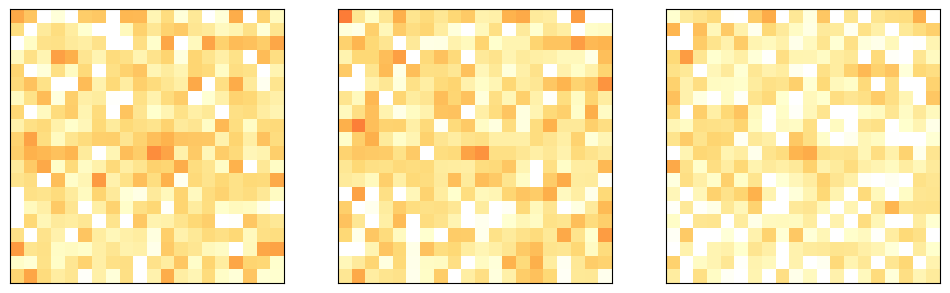

chr1              chr17
start1         80453001
end1           80458000
annotation1           E
seqnames2         chr17
start2         80543001
end2           80548000
annotation2           P
pair                E-P
Name: 7, dtype: object
0
1
2


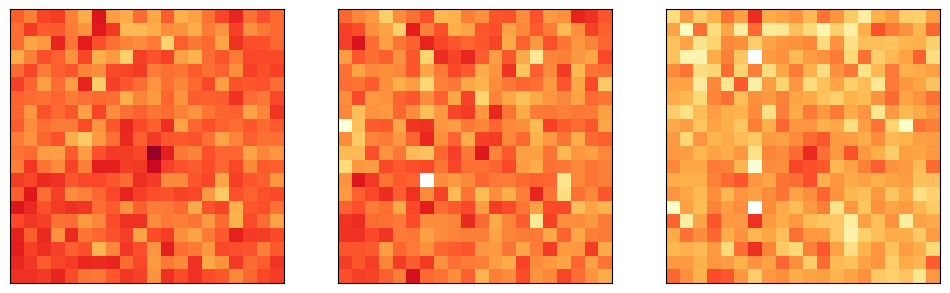

chr1              chr17
start1         80453001
end1           80458000
annotation1           E
seqnames2         chr17
start2         80989001
end2           80994000
annotation2           P
pair                E-P
Name: 8, dtype: object
0
1
2


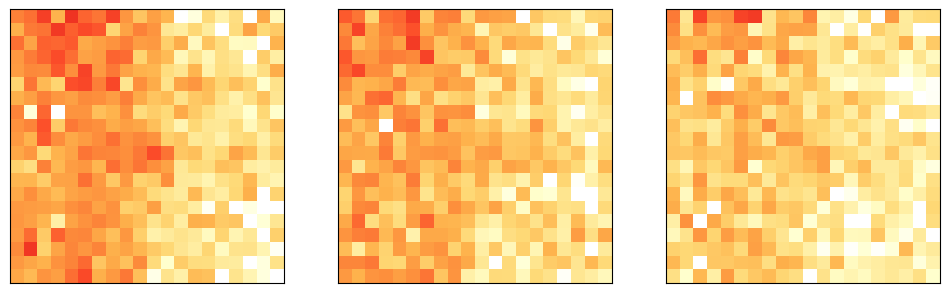

chr1              chr17
start1         80455001
end1           80460000
annotation1           E
seqnames2         chr17
start2         80474001
end2           80479000
annotation2           P
pair                E-P
Name: 9, dtype: object
0
1
2


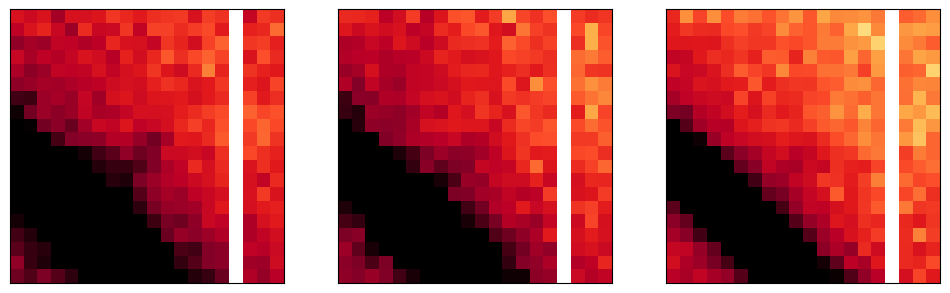

chr1              chr17
start1         80476001
end1           80481000
annotation1           P
seqnames2         chr17
start2         80969001
end2           80974000
annotation2           P
pair                P-P
Name: 10, dtype: object
0
1
2


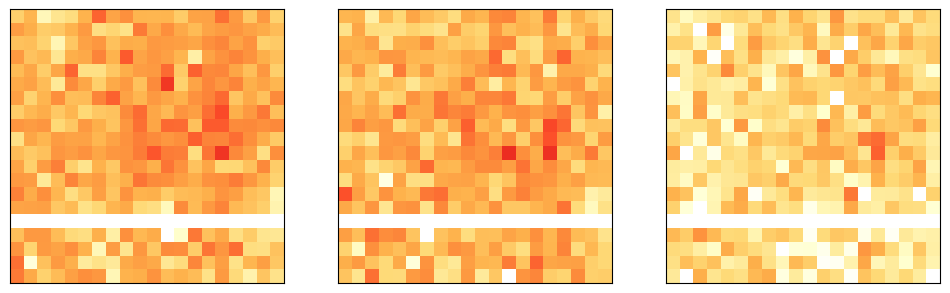

chr1              chr17
start1         80475001
end1           80480000
annotation1           P
seqnames2         chr17
start2         80979001
end2           80984000
annotation2        CTCF
pair             P-CTCF
Name: 11, dtype: object
0
1
2


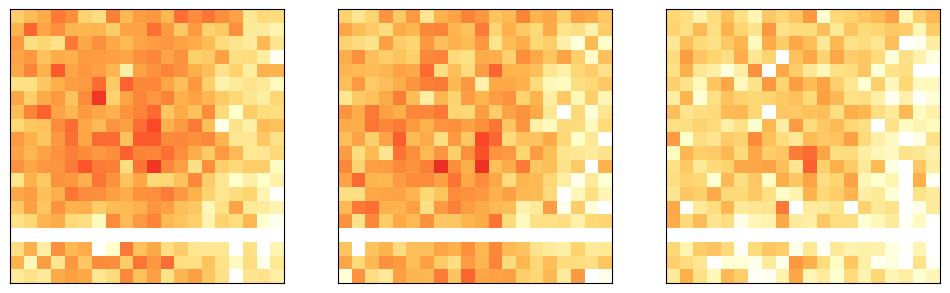

chr1              chr17
start1         80476001
end1           80481000
annotation1           P
seqnames2         chr17
start2         80573001
end2           80578000
annotation2        CTCF
pair             P-CTCF
Name: 12, dtype: object
0
1
2


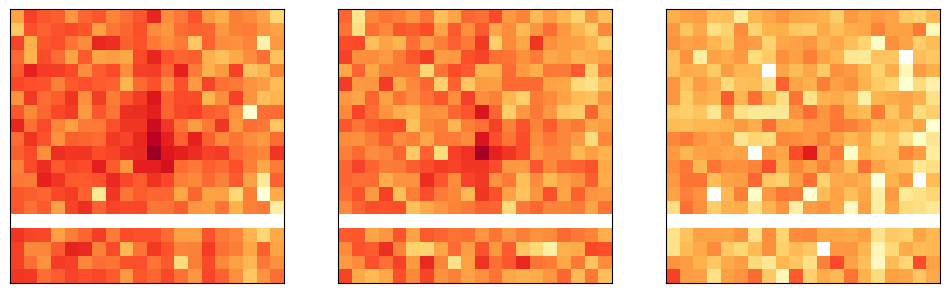

chr1               chr17
start1          80480001
end1            80485000
annotation1         Null
seqnames2          chr17
start2          80924001
end2            80929000
annotation2         Null
pair           Null-Null
Name: 13, dtype: object
0
1
2


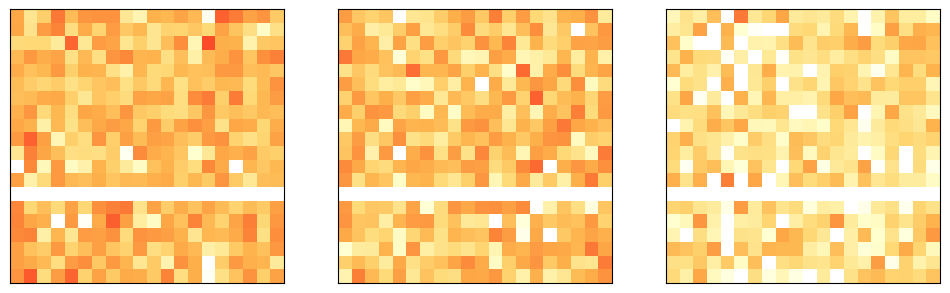

chr1               chr17
start1          80482001
end1            80487000
annotation1         Null
seqnames2          chr17
start2          80948001
end2            80953000
annotation2         Null
pair           Null-Null
Name: 14, dtype: object
0
1
2


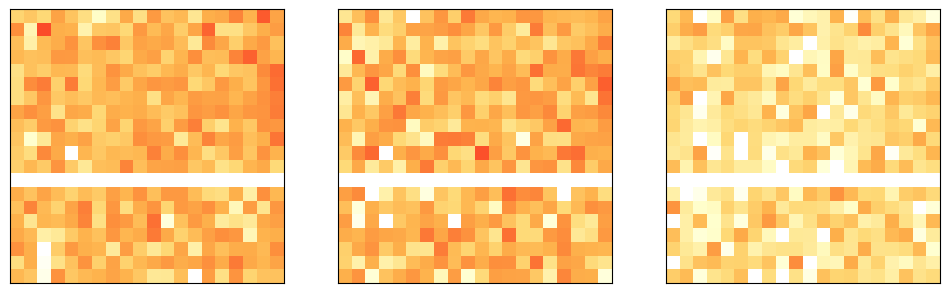

chr1               chr17
start1          80492001
end1            80497000
annotation1         Null
seqnames2          chr17
start2          80978001
end2            80983000
annotation2         CTCF
pair           CTCF-Null
Name: 15, dtype: object
0
1
2


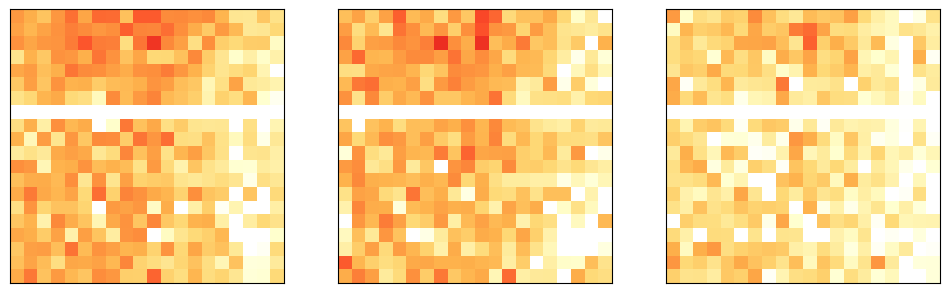

chr1              chr17
start1         80573001
end1           80578000
annotation1        CTCF
seqnames2         chr17
start2         80891001
end2           80896000
annotation2           E
pair             E-CTCF
Name: 16, dtype: object
0
1
2


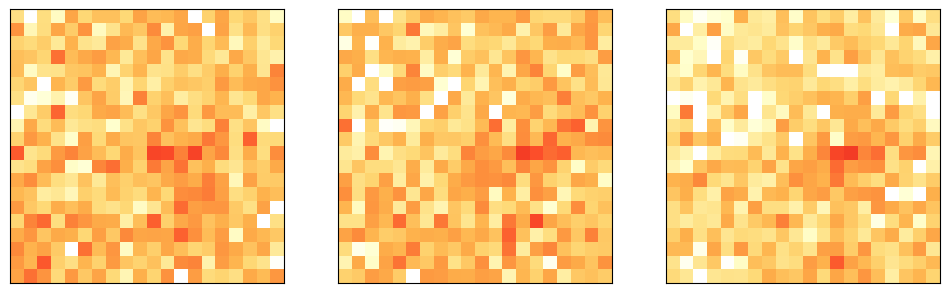

chr1               chr17
start1          80573001
end1            80578000
annotation1         CTCF
seqnames2          chr17
start2          80897001
end2            80902000
annotation2         CTCF
pair           CTCF-CTCF
Name: 17, dtype: object
0
1
2


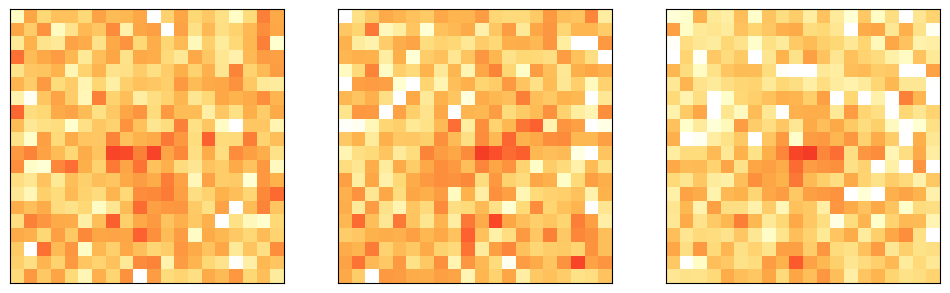

chr1              chr17
start1         80573001
end1           80578000
annotation1        CTCF
seqnames2         chr17
start2         80969001
end2           80974000
annotation2           P
pair             P-CTCF
Name: 18, dtype: object
0
1
2


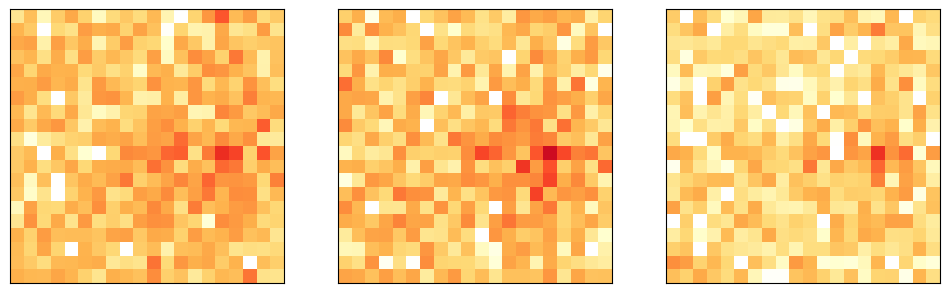

chr1               chr17
start1          80573001
end1            80578000
annotation1         CTCF
seqnames2          chr17
start2          80979001
end2            80984000
annotation2         CTCF
pair           CTCF-CTCF
Name: 19, dtype: object
0
1
2


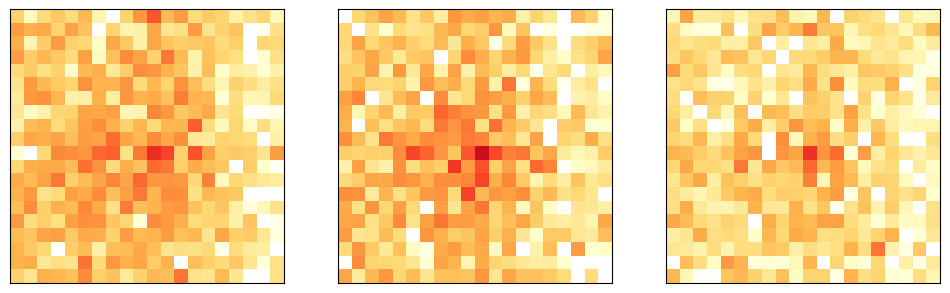

chr1              chr17
start1         80863001
end1           80868000
annotation1        CTCF
seqnames2         chr17
start2         80968001
end2           80973000
annotation2           P
pair             P-CTCF
Name: 20, dtype: object
0
1
2


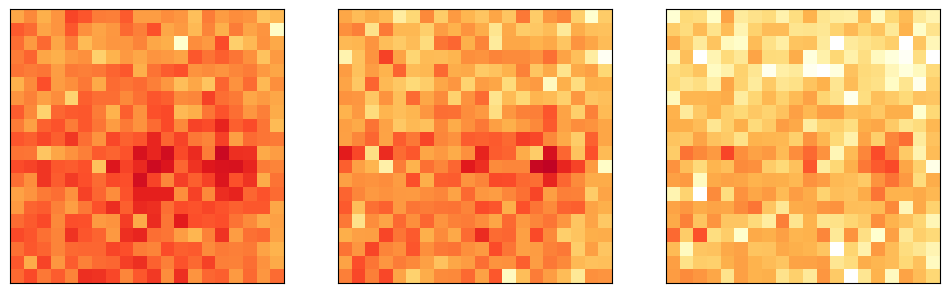

chr1               chr17
start1          80864001
end1            80869000
annotation1         CTCF
seqnames2          chr17
start2          80896001
end2            80901000
annotation2         CTCF
pair           CTCF-CTCF
Name: 21, dtype: object
0
1
2


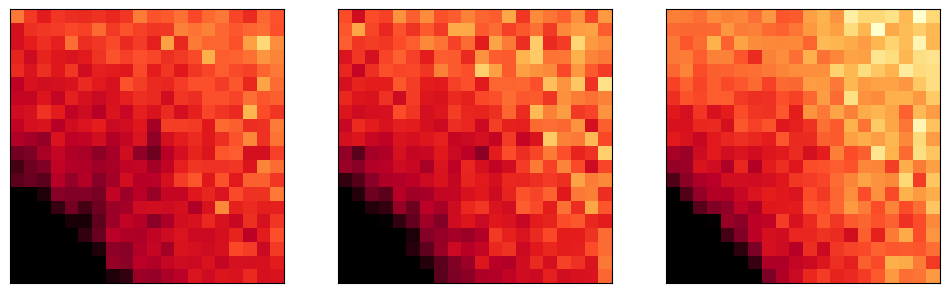

chr1               chr17
start1          80864001
end1            80869000
annotation1         CTCF
seqnames2          chr17
start2          80979001
end2            80984000
annotation2         CTCF
pair           CTCF-CTCF
Name: 22, dtype: object
0
1
2


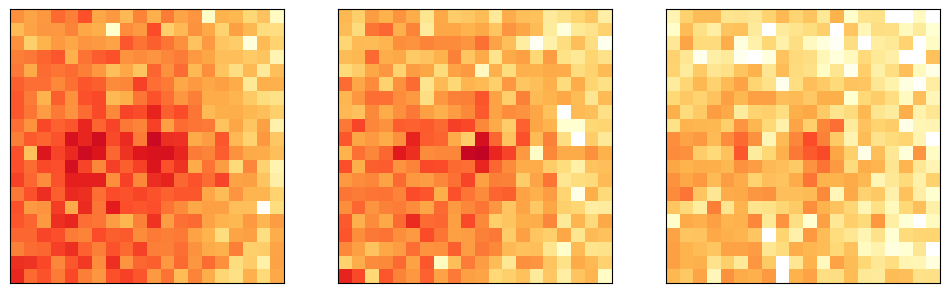

chr1              chr17
start1         80989001
end1           80994000
annotation1           P
seqnames2         chr17
start2         81018001
end2           81023000
annotation2           E
pair                E-P
Name: 23, dtype: object
0
1
2


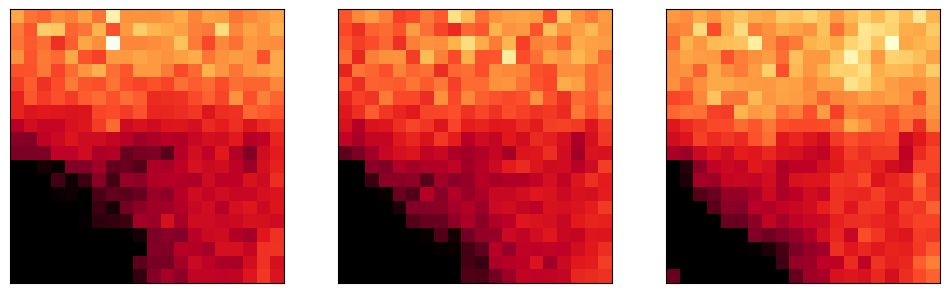

chr1              chr17
start1         80989001
end1           80994000
annotation1           P
seqnames2         chr17
start2         81033001
end2           81038000
annotation2           P
pair                P-P
Name: 24, dtype: object
0
1
2


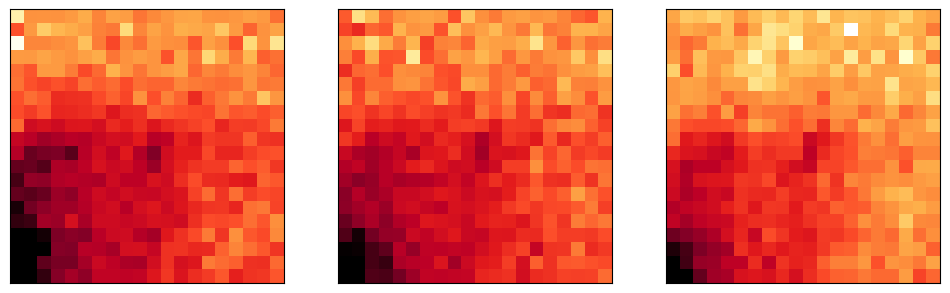

chr1              chr17
start1         81002001
end1           81007000
annotation1           E
seqnames2         chr17
start2         81015001
end2           81020000
annotation2           E
pair                E-E
Name: 25, dtype: object
0
1
2


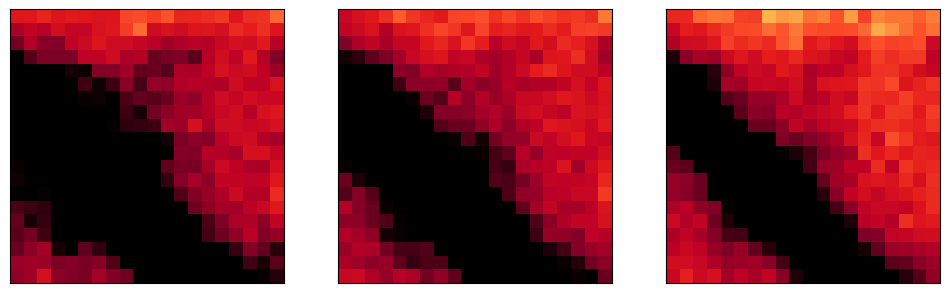

chr1               chr17
start1          80424501
end1            80429500
annotation1         CTCF
seqnames2          chr17
start2          80862501
end2            80867500
annotation2         CTCF
pair           CTCF-CTCF
Name: 26, dtype: object
0
1
2


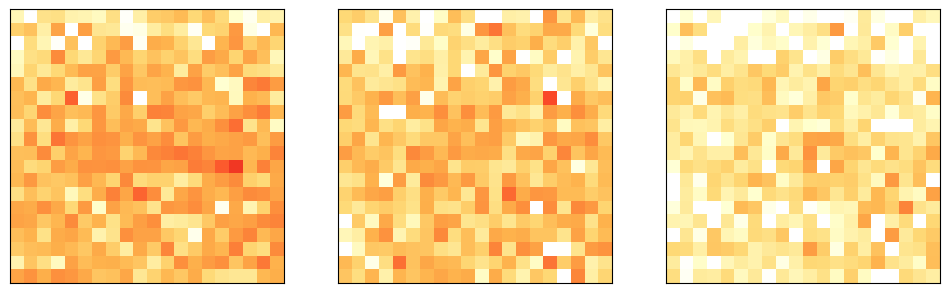

chr1              chr17
start1         80476501
end1           80481500
annotation1           P
seqnames2         chr17
start2         80898501
end2           80903500
annotation2        CTCF
pair             P-CTCF
Name: 27, dtype: object
0
1
2


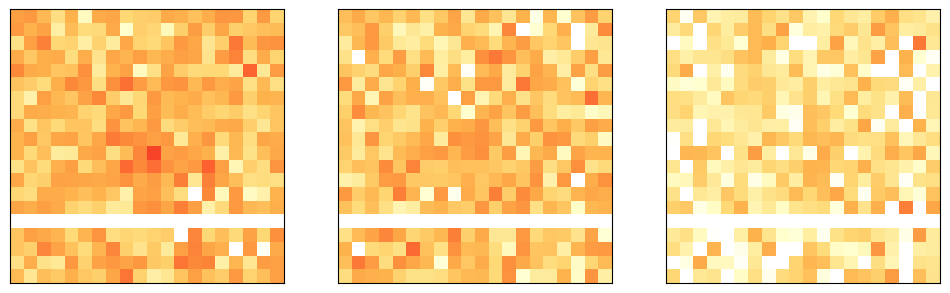

In [49]:
plot_loops_region(regions['cre_vs_ctcf'], loopcalls_sub, resolution, size_kb=20)

chr1          chr8
start1    77800000
end1      77800000
chr2          chr8
start2    78250000
end2      78250000
Name: 0, dtype: object
0
chr8:75561811-79081548
1
chr8:75561811-79081548
2
chr8:75561811-79081548


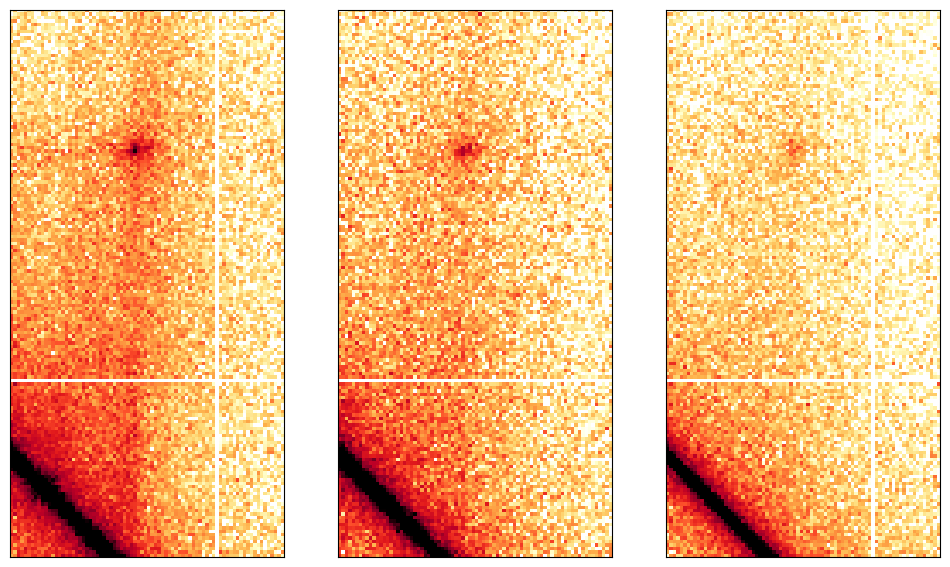

In [74]:
boundary = pd.DataFrame({'chr1':['chr8'],'start1':[77_800_000],'end1':[77_800_000],
                         'chr2':['chr8'],'start2':[78_250_000],'end2':[78_250_000]})
plot_loops_region("chr8:75561811-79081548",boundary, resolution, size_kb=400, size_kb2=200, 
                  vmin=0.0001, vmax=0.01, sd=os.path.join(savedir, 'boundary_disappear_insets.svg'))

chr1           chr5
start1    149750000
end1      149750000
chr2           chr5
start2    151500000
end2      151500000
Name: 0, dtype: object
0
chr5:149023111-152003168
1
chr5:149023111-152003168
2
chr5:149023111-152003168


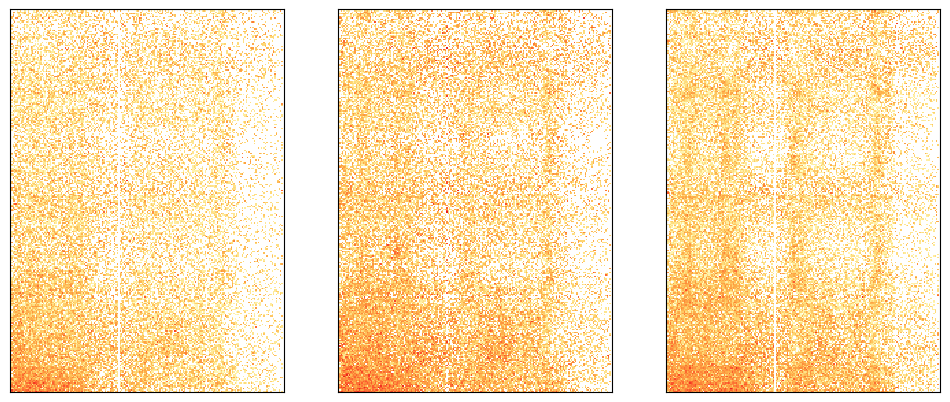

In [79]:
compt = pd.DataFrame({'chr1':['chr5'],'start1':[149_750_000],'end1':[149_750_000],
                         'chr2':['chr5'],'start2':[151_500_000],'end2':[151_500_000]})
plot_loops_region("chr5:149023111-152003168",compt, resolution, size_kb=700, size_kb2=500, 
                  vmin=0.00001, vmax=0.005, sd=None)

chr1           chr5
start1    173750000
end1      173750000
chr2           chr5
start2    173850000
end2      173850000
Name: 0, dtype: object
0
1
2


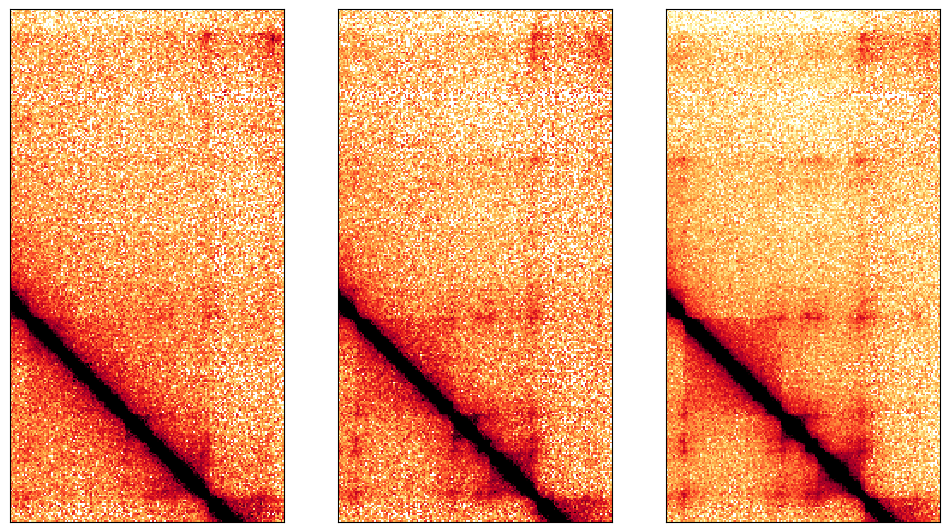

In [26]:
cpeb = pd.DataFrame({'chr1':['chr5'],'start1':[173_750_000],'end1':[173_750_000],
                         'chr2':['chr5'],'start2':[173_850_000],'end2':[173_850_000]})
plot_loops_region('chr5:173570169-174026097',cpeb, resolution, size_kb=150, size_kb2=80, 
                  vmin=0.00005, vmax=0.008, sd=os.path.join(savedir, 'cpeb_insets.svg'))

In [27]:
cre_changing = pd.DataFrame({'chr1':['chr19'],'start1':[49_500_000],'end1':[49_500_000],
                         'chr2':['chr19'],'start2':[49_600_000],'end2':[49_600_000]})
plot_loops_region("chr19:49314500-49733500'",cre_changing, resolution, size_kb=150, size_kb2=100, 
                  vmin=0.00005, vmax=0.008, sd=None)

#sd=os.path.join(savedir, "changing_cre_insets.svg")


chr1         chr19
start1    49300000
end1      49300000
chr2         chr19
start2    49700000
end2      49700000
Name: 0, dtype: object
0
1


/tmp/ipykernel_2490001/1920085940.py:60: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im2 = ax.matshow(


2


In [ ]:
sox6 = pd.DataFrame({'chr1':['chr11', 'chr11'],'start1':[16_190_000, 16_378_000],'end1':[16_190_000, 16_378_000],
                         'chr2':['chr11','chr11'],'start2':[16_605_000,16_605_000],'end2':[16_605_000,16_605_000]})
plot_loops_region("chr11:16066449-16709591",sox6, resolution, size_kb=15, size_kb2=15, 
                  vmin=0.00005, vmax=0.008, sd=os.path.join(savedir, 'sox6_insets.svg'))